In [ ]:
'''
Logistic Regression
--------------------
- Used for binary classification.
- Use sigmoid function to predict data.
- Sigmoid Function and AUC-ROC Curve.

- Train Test Split
- Stratification (Stratify) -> Only for target data
train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

Logistic Model Arguments
-------------------
solver = liblinear, lbfgs(default), saga
class_weight = None(default), balanced
random_state = None(default) / index

Classification Metrics
-----------------
1. Classification Report
2. Confusion Matrix

Columns
---------
Gender - (1 -> Female and 2 -> Male)
Cholesterol / Glucose - (1 -> Low, 2 -> Mild, 3 -> High)
Smoke / Alco / Active / Cardio - (0 - No, 1 - Yes)

'''

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Logistic Regression
from sklearn.linear_model import LogisticRegression
# Train Test Split
from sklearn.model_selection import train_test_split
# Feature Scaling
from sklearn.preprocessing import StandardScaler
# Classification Metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

In [31]:
df = pd.read_csv('Dataset/Cardiovascular_Disease.csv')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [32]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [33]:
df['age'] = df['age']//365

In [35]:
columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
for col in columns:
    skew_val = filtered_df[col].skew()
    print(f'{col}: {skew_val}')

age: -0.2850026121405712
height: 0.27173762169526344
weight: 0.5235845166799745
ap_hi: 0.6249774551983979
ap_lo: -0.5963342027164668


<Axes: ylabel='weight'>

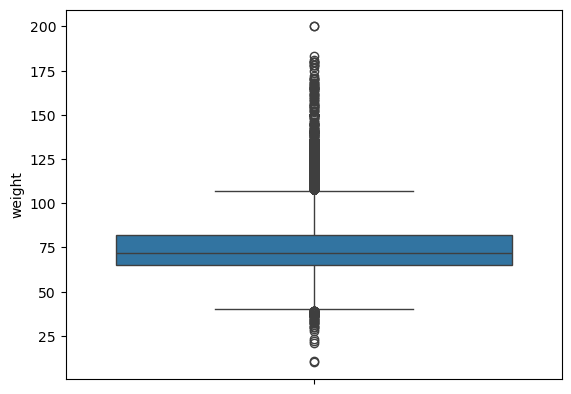

In [36]:
sns.boxplot(df['weight'])

In [37]:
df['age'].min()

29

In [38]:
filtered_df = df[
    (df['height'].between(150, 190)) &
    (df['weight'].between(45, 110)) &
    (df['ap_hi'].between(90, 180)) &
    (df['ap_lo'].between(50, 90))
]

## Feature and Target

In [39]:
features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
target = 'cardio'

In [40]:
X = filtered_df[features]
Y = filtered_df[target]

## Train Test Split

In [41]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

## Feature Scaling

In [42]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

## Model Implementation

In [43]:
model = LogisticRegression(
    solver='lbfgs', class_weight='balanced', random_state=42
)
model.fit(X_train_scale, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [44]:
Y_pred = model.predict(X_test_scale)
Y_pred

array([0, 0, 0, ..., 1, 1, 0], shape=(12190,))

## Metrics

In [45]:
cr = classification_report(Y_test, Y_pred)
cm = confusion_matrix(Y_test, Y_pred)

In [16]:
'''
Macro Avg
----------
(p1 + p2 + ... + pn)/n

Weighted Avg
---------------
((p1 * sup) + (p2 * sup) + ... + (p.n * sup.n))/total_support
'''

'\nMacro Avg\n----------\n(p1 + p2 + ... + pn)/n\n\nWeighted Avg\n---------------\n((p1 * sup) + (p2 * sup) + ... + (p.n * sup.n))/total_support\n'

In [46]:
print(cr)

              precision    recall  f1-score   support

           0       0.73      0.77      0.75      6526
           1       0.71      0.67      0.69      5664

    accuracy                           0.72     12190
   macro avg       0.72      0.72      0.72     12190
weighted avg       0.72      0.72      0.72     12190



In [47]:
print(cm)

[[5014 1512]
 [1893 3771]]


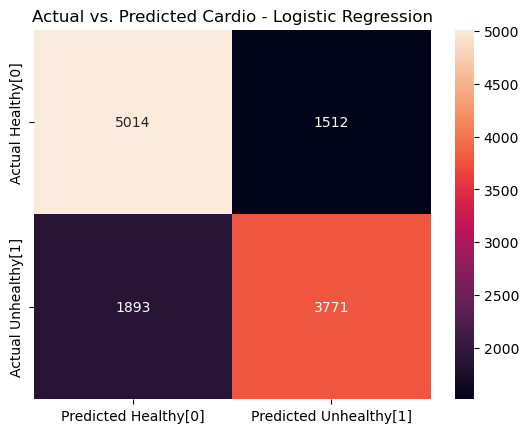

In [48]:
sns.heatmap(cm, annot=True, fmt='1.0f', xticklabels=['Predicted Healthy[0]', 'Predicted Unhealthy[1]'],
           yticklabels=['Actual Healthy[0]', 'Actual Unhealthy[1]'])
plt.title('Actual vs. Predicted Cardio - Logistic Regression')
plt.show()

## ROC-AUC Curve

In [ ]:
'''
Process of Calculating ROC-AUC Curve
---------------------------------------
1. Calculate Probability

2. Calculate True Positive Rate (tpr) and False Positive Rate (fpr)
    -> tpr = tp / (tp - fn)
    -> fpr = fp / (fp - tn)

3. Best Threshold Positition
    -> Using J Score (tpr - fpr)
'''

In [51]:
# Probability
Y_prob = model.predict_proba(X_test_scale)[:,1]
Y_prob

array([0.43007214, 0.46459465, 0.27784875, ..., 0.76140706, 0.75164967,
       0.37862714], shape=(12190,))

In [54]:
# Calculate tpr and fpr -> Used to create curve line to find threshold position
tn, fp, fn, tp = cm.ravel()

tpr_default = tp / (tp - fn)
fpr_default = fp / (fp - tn)

print(f'True Positive Rate (TPR): {tpr_default}')
print(f'False Positive Rate (FPR): {fpr_default}')

True Positive Rate (TPR): 2.0079872204472844
False Positive Rate (FPR): -0.431753283837807


In [62]:
# Find best position for TPR, FPR and Threshold
fpr, tpr, threshold = roc_curve(Y_test, Y_prob)
auc_score = roc_auc_score(Y_test, Y_prob)

print(f'AUC Score: {auc_score}')

AUC Score: 0.7756492094421099


In [68]:
j_score = tpr - fpr

best_idx = np.argmax(j_score)

best_tpr = tpr[best_idx]
best_fpr = fpr[best_idx]
best_threshold = threshold[best_idx]

print(f'Best Threshold: {best_threshold}')

Best Threshold: 0.5019688451288992


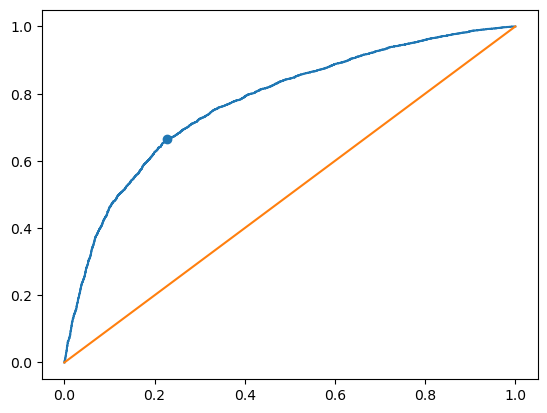

In [67]:
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.scatter(best_fpr, best_tpr)

In [71]:
# Y_cr = classification_report(Y_test, auc_score)